# (19) Retina+V1: MNIST

host: ```mach```, device: ```cuda:3```

**motivation:** <br>

MNIST

two layers:
- Retina (Gaussian + Logistic)
- V1 (Poisson)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.config import Config


device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Fit

In [3]:
cfg_layers = [
    CFG_CLASSES['gaus'](t_repeats=1, beta_outer=256.0, n_latents=64, latent_act='logistic'),
    CFG_CLASSES['pois'](t_repeats=1, beta_outer=256.0, n_latents=256, clamp_u=5, clamp_du=7),
]
cfg = Config(
    dataset='MNIST',
    cfg_layers=cfg_layers,
    t_train=128,
    t_warmup=32,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(epochs=500),
    device=device,
)
tr.n_iters

150000

In [5]:
print(tr.model)

RetinaV1(
  (layers): ModuleDict(
    (g0): GaussianLogisticLayer(input_dim=784, latent_dim=64, temperature=1, beta_inner=1, eps=1)
    (p1): PoissonLayer(input_dim=784, latent_dim=256, temperature=1, beta_inner=1, eps=1)
  )
)

In [6]:
tr.print()

MNIST_m(g0+logi,p1)_t(32+128×(1,1))_b(256,256)_k(64,256)
b200-ep500-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_22,23:07)

In [7]:
cm = 'tight-clamp+debug-fisher-xi'
fit_name = f"{cm}_{tr.cfg.name()}"
tr.train(fit_name)

# tr.train()

epoch # 500, avg loss: -971.781: 100%|████| 500/500 [56:52:52<00:00, 409.55s/it]


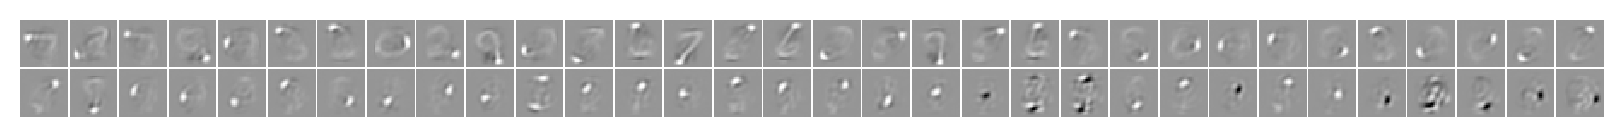

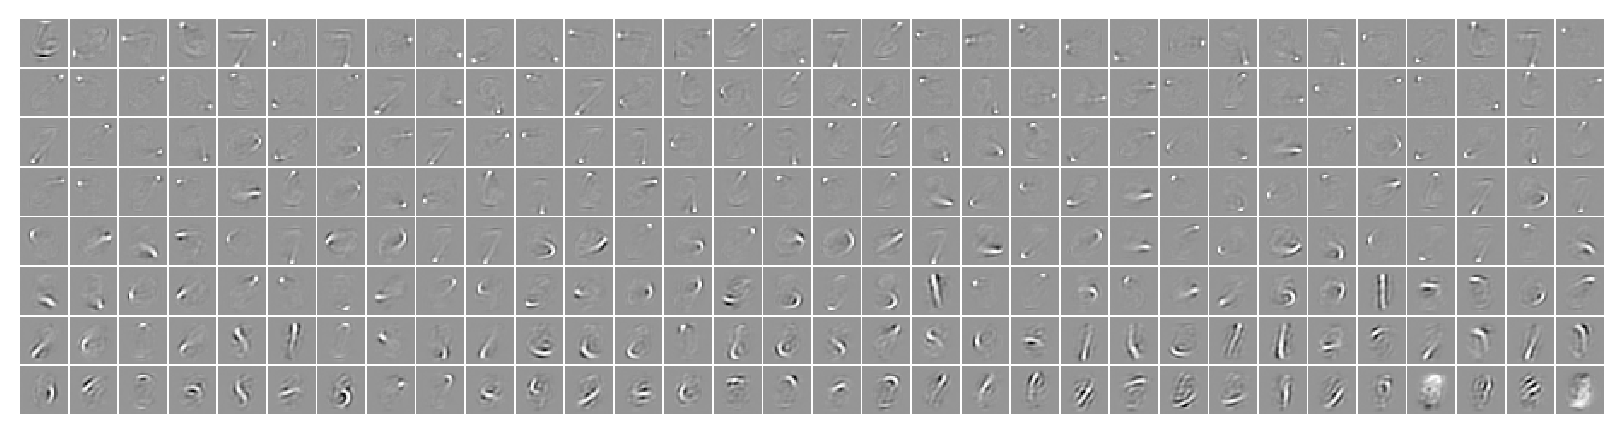

In [8]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for i, (k, v) in enumerate(u0.items()):
    kws = dict(
        order=np.argsort(v),
        nrows=max(1, tr.model.cfg.n_latents[i] // 32),
        method='abs-max',
    )
    tr.model.show(k, **kws);

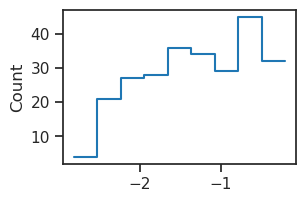

In [9]:
histplot(u0['p1'])
plt.show()

In [10]:
{k: [llr.exp().item() for llr in lay.log_lr] for k, lay in tr.model.layers.items()}

{'g0': [0.026467863470315933, 0.007000886369496584],
 'p1': [0.02754335291683674]}

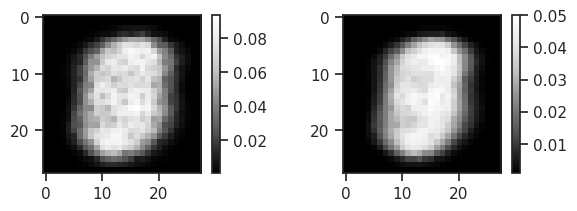

In [11]:
var = {}
for name, layer in tr.model.layers.items():
    log_sigma = layer.get_dec_log_sigma()
    variance = tonp(torch.exp(log_sigma * 2).squeeze())
    variance = variance.reshape(tr.model.cfg.input_sz)
    variance = np.transpose(variance, (1, 2, 0))
    var[name] = variance

fig, axes = create_figure(1, len(var))

for i, (name, x2p) in enumerate(var.items()):
    im = axes[i].imshow(var[name], cmap='Greys_r')
    plt.colorbar(im, ax=axes[i])

plt.show()

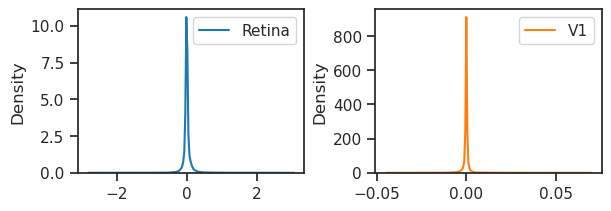

In [12]:
fig, axes = create_figure(1, 2)

sns.kdeplot(tonp(tr.model.layers['g0'].get_weight().ravel()), color='C0', label='Retina', ax=axes[0])
sns.kdeplot(tonp(tr.model.layers['p1'].get_weight().ravel()), color='C1', label='V1', ax=axes[1])

add_legend(axes)
plt.show()

In [13]:
tr.cfg.batch_size = 3000
tr.setup_data()

In [14]:
%%time


items = ['mse', 'r2', 'u', 'samples']

t_total = 1000

r2 = {k: np_nans(t_total) for k in tr.model.layers}
mse = {k: np_nans(t_total) for k in tr.model.layers}

true = []
pred = collections.defaultdict(list)
error = collections.defaultdict(list)

state = collections.defaultdict(list)
samples = collections.defaultdict(list)

for x, *_ in tqdm(iter(tr.dl_vld)):
    tr.model.reset_inference_state(len(x))
    feeder = tr.get_feeder(x)
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = feeder[t]
        extras = tr.model.xtract_ftr(
            inpt, return_extras=items)[-1]
        for k, d in extras.items():
            r2[k][t] = d['r2'].mean(0).item()
            mse[k][t] = d['mse'].mean(0).item()

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            for k, layer in tr.model.layers.items():
                pred[k].append(layer.conditional.loc)
                state[k].append(extras[k]['u'])
                samples[k].append(extras[k]['samples'])
                error[k].append(extras[k]['error'])

torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = {k: torch.cat(v) for k, v in pred.items()}
error = {k: torch.cat(v) for k, v in error.items()}
state = {k: torch.cat(v) for k, v in state.items()}
samples = {k: torch.cat(v) for k, v in samples.items()}

100%|█████████████████████████████████████████████| 4/4 [00:59<00:00, 14.97s/it]


CPU times: user 1min 12s, sys: 953 ms, total: 1min 13s
Wall time: 1min


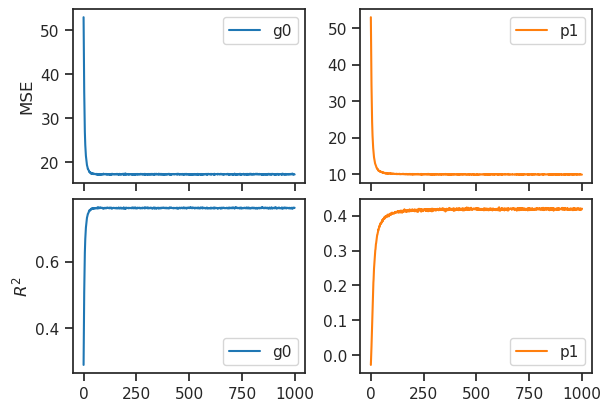

In [15]:
fig, axes = create_figure(2, len(tr.model.layers), sharex='all')

for i, name in enumerate(tr.model.layers):
    axes[0, i].plot(mse[name], color=f'C{i}', label=name)
    axes[1, i].plot(r2[name], color=f'C{i}', label=name)
axes[0, 0].set(ylabel='MSE')
axes[1, 0].set(ylabel=r'$R^2$')
add_legend(axes)
plt.show()

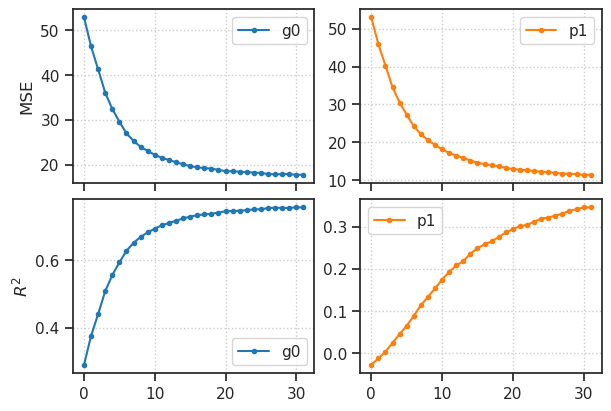

In [16]:
fig, axes = create_figure(2, len(tr.model.layers), sharex='all')

intvl = range(32)

for i, name in enumerate(tr.model.layers):
    axes[0, i].plot(mse[name][intvl], marker='.', color=f'C{i}', label=name)
    axes[1, i].plot(r2[name][intvl], marker='.', color=f'C{i}', label=name)
axes[0, 0].set(ylabel='MSE')
axes[1, 0].set(ylabel=r'$R^2$')
add_legend(axes)
add_grid(axes)
plt.show()

In [17]:
r2['p1'][-10:]

array([0.4201299 , 0.41656786, 0.42120376, 0.41937378, 0.41856918,
       0.41957405, 0.41961104, 0.41796225, 0.41880074, 0.42053971])

In [18]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

In [19]:
def _reshape_transpose(x):
    x2p = tonp(x).reshape(tr.model.cfg.input_sz)
    x2p = np.transpose(x2p, (1, 2, 0))
    return x2p


def _plot_selected_samples(select_from=None, ncols=20, seed=0):
    rng = get_rng(seed)

    nrows = 6
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(_reshape_transpose(true[idx]), cmap='Greys_r')
        axes[1, i].imshow(_reshape_transpose(pred['g0'][idx]), cmap='Greys_r')
        axes[2, i].imshow(_reshape_transpose(error['g0'][idx]), cmap='Greys_r')
        # axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
        axes[4, i].imshow(_reshape_transpose(pred['p1'][idx]), cmap='Greys_r')
        axes[5, i].imshow(_reshape_transpose(error['p1'][idx]), cmap='Greys_r')

    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred\n(retina)', fontsize=15)
    axes[2, 0].set_ylabel('error\n(retina)', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    axes[4, 0].set_ylabel('pred\n(v1)', fontsize=15)
    axes[5, 0].set_ylabel('error\n(v1)', fontsize=15)

    remove_ticks(axes, False)
    plt.show()

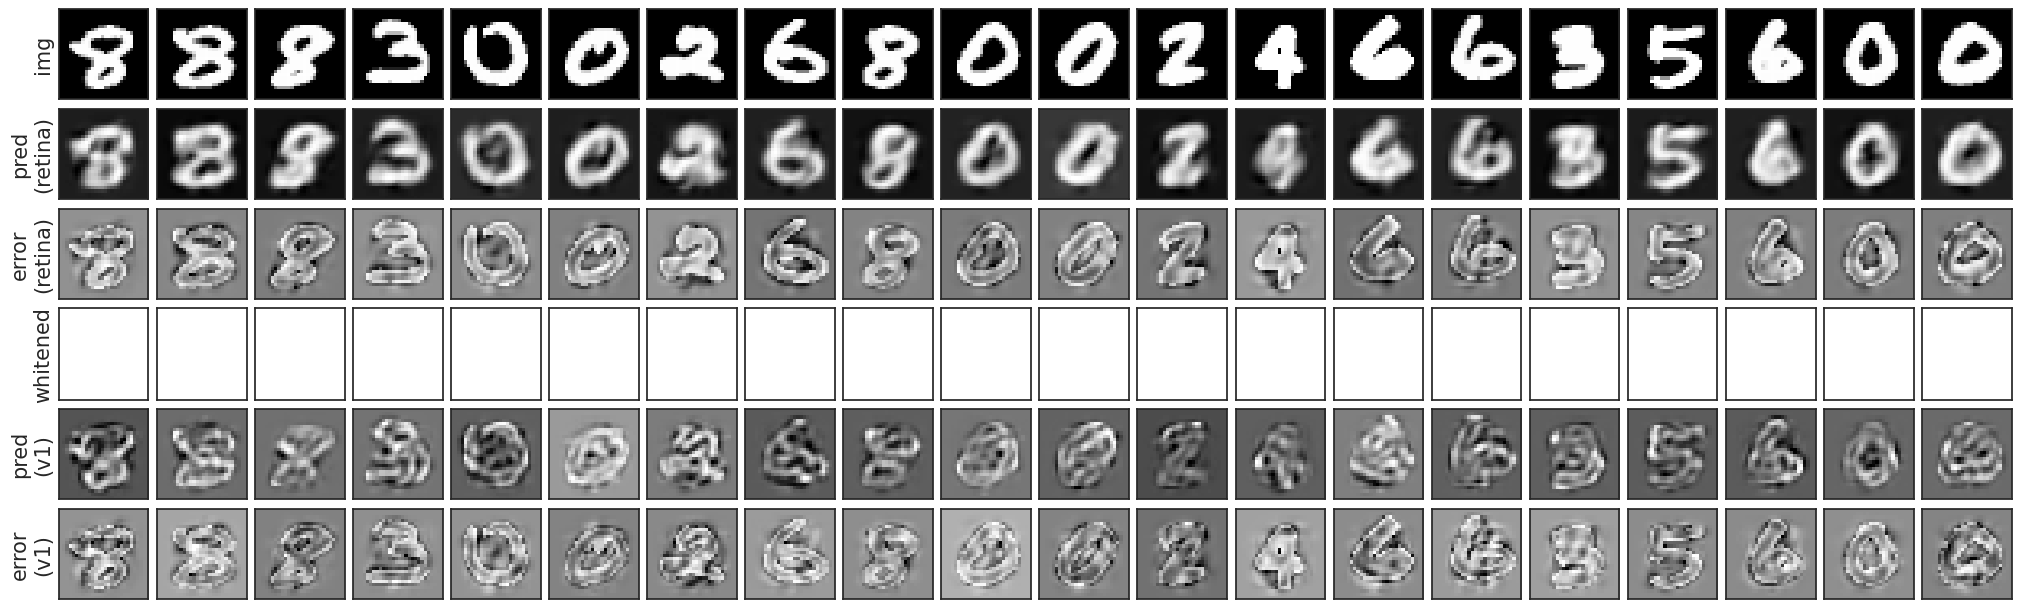

In [20]:
_plot_selected_samples()

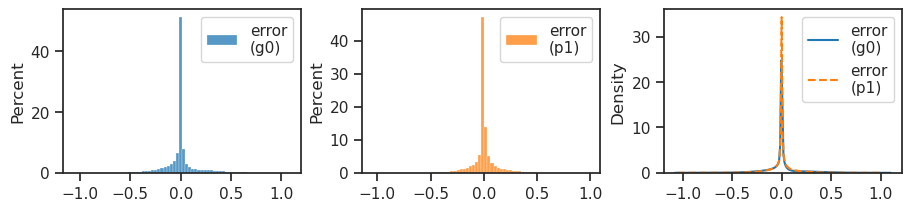

In [21]:
fig, axes = create_figure(1, len(error) + 1)

for i, (name, x2p) in enumerate(error.items()):
    sns.histplot(tonp(x2p.ravel()), stat='percent', bins=70, color=f'C{i}', label=f'error\n({name})', ax=axes[i])
    sns.kdeplot(tonp(x2p.ravel()), color=f'C{i}', label=f'error\n({name})', ls='-' if i % 2 == 0 else '--', ax=axes[-1])
add_legend(axes)
plt.show()

In [22]:
for name, z in samples.items():
    life, pop, portions = sparse_score(z, cutoff=0.01)
    print(f"layer: {name}\nlifetime: {life.mean().item():0.3f}\nportions:{portions}\n")

layer: g0
lifetime: 0.456
portions:{'0': 98.9, '1': 1.1, 'inf+': 0}

layer: p1
lifetime: 0.917
portions:{'0': 86.0, '1': 6.0, '2': 2.9, '3': 1.7, '4': 1.1, '5': 0.7, '6+': 1.6}

In [23]:
print(tr.model.layers['p1'].n_exp)
tr.model.layers['p1'].posterior.n_exp

tensor([ 5,  5,  8, 14, 24, 37, 49, 55, 58, 59, 60, 60, 60, 59, 60, 59, 60, 59,
        59, 59, 59, 59, 59, 59, 59, 59, 59, 58, 58, 59, 60, 59, 59, 59, 59, 60,
        59, 59, 59, 59, 59, 59, 59, 58, 59, 58, 59, 59, 59, 58, 58, 58, 59, 59,
        59, 59, 59, 58, 59, 59, 59, 59, 59, 59, 58, 59, 59, 59, 58, 59, 58, 59,
        59, 59, 59, 59, 60, 59, 59, 58, 58, 59, 58, 59, 59, 59, 59, 60, 59, 59,
        59, 59, 59, 59, 58, 58, 59, 59, 58, 59, 59, 59, 59, 59, 59, 59, 59, 59,
        59, 59, 59, 59, 59, 58, 59, 59, 59, 59, 59, 59, 60, 59, 59, 59, 59, 59,
        59, 59], device='cuda:3', dtype=torch.int32)

65

## clf

In [3]:
# a = 'MNIST_m(g0+logi,p1)_t(16+64×(1,1))_b(128,64)_k(128,512)'
# b = 'b200-ep500-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_20,18:52)'
# tr, meta = load_model(pjoin(a, b), device=device)
# meta['checkpoint']

350

In [24]:
from analysis.linear import clf_score

In [49]:
output = clf_score(tr)
df = output['df_accu'].copy()
df.shape

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.89s/it]


(44, 4)

In [52]:
_df = df.loc[df['split'] == 'vld']
_df

,time,layer,split,accu
1,1,g0,vld,0.8506
3,1,p1,vld,0.8771
5,100,g0,vld,0.9115
7,100,p1,vld,0.9352
9,200,g0,vld,0.9110
11,200,p1,vld,0.9353
13,300,g0,vld,0.9128
15,300,p1,vld,0.9358
17,400,g0,vld,0.9109
19,400,p1,vld,0.9339


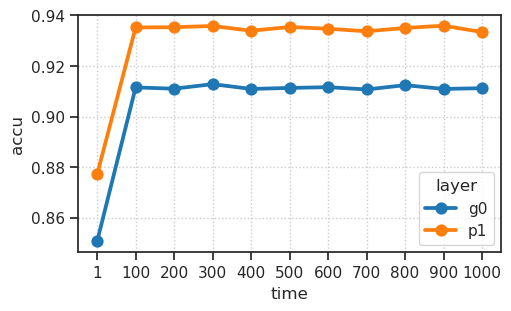

In [53]:
fig, ax = create_figure(1, 1, (5, 3))
sns.pointplot(data=_df, x='time', y='accu', hue='layer', ax=ax)
ax.grid()
plt.show()

In [55]:
results, times, ground_truths = _process(
    trainer=tr,
    t_total=500,
    save_freq=50,
    data_batch_sz=5000,
    verbose=True,
)

100%|███████████████████████████████████| 2/2 [00:16<00:00,  8.11s/it]


In [60]:
u_retina = results['trn']['g0']['state'][:, -1, :]
z_retina = tonp(tr.model.layers['g0'].apply_act_fn(tr.to(u_retina)))

u_v1 = results['trn']['g0']['state'][:, -1, :]
z_v1 = np.exp(u_v1)

z = np.concatenate([z_retina, z_v1], axis=1)
z.shape

(60000, 128)

In [61]:
u_retina = results['vld']['g0']['state'][:, -1, :]
z_retina = tonp(tr.model.layers['g0'].apply_act_fn(tr.to(u_retina)))

u_v1 = results['vld']['g0']['state'][:, -1, :]
z_v1 = np.exp(u_v1)

z_vld = np.concatenate([z_retina, z_v1], axis=1)
z_vld.shape

(10000, 128)

In [62]:
lr = linear_model.LogisticRegression().fit(
    X=z, y=ground_truths['trn'])

In [63]:
classification_report(
    y_true=ground_truths['vld'],
    y_pred=lr.predict(z_vld),
    output_dict=True,
)['accuracy']

0.9022

## White noise

In [30]:
from analysis.sta import perform_sta_analysis
from utils.animation import show_movie

In [31]:
sta = perform_sta_analysis(tr, t_total=1, n_trials=100, batch_size=10_000)

100%|█████████████████████████████████████████| 100/100 [47:10<00:00, 28.31s/it]


In [32]:
n_lags = 80
s_kers = {
    name: np_nans((len(sta_array), 16, 16))
    for name, sta_array in sta.items()
}
t_kers = {
    name: np_nans((len(sta_array), n_lags + 1))
    for name, sta_array in sta.items()
}

for name, sta_array in sta.items():
    for i in range(len(sta_array)):
        uu, ss, vvh = torch.linalg.svd(
            sta_array[i], full_matrices=False)
    
        s_kers[name][i] = tonp(vvh[0]).reshape(16, 16)
        t_kers[name][i] = tonp(uu[:, 0])

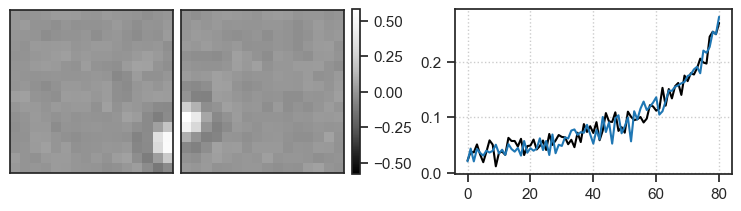

In [33]:
name = 'g0'
i, j = 44, 68
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

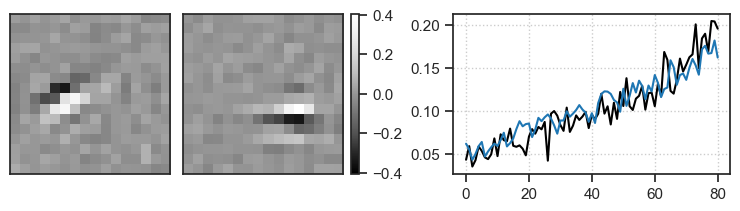

In [34]:
name = 'p1'
i, j = 57, 25
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

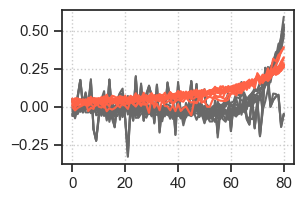

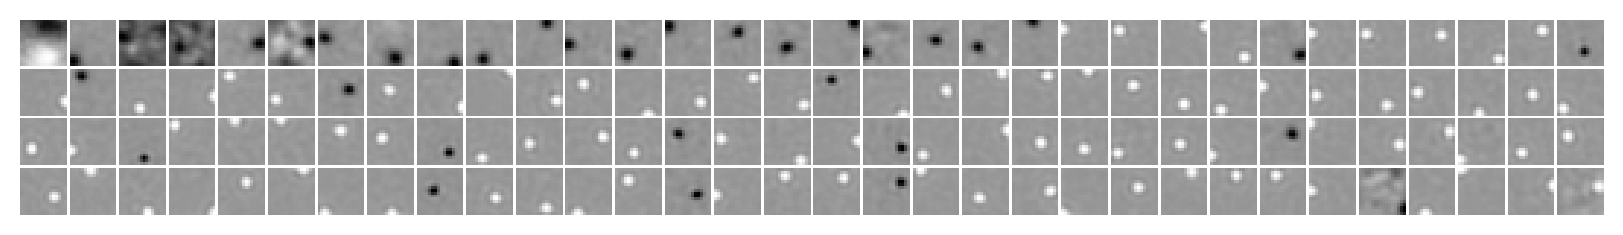

In [35]:
order = np.argsort(t_kers['g0'][:, 70])

plot(t_kers['g0'][order][:13].T, color='dimgrey');
plot(t_kers['g0'][order][-13:].T, color='tomato');
plt.grid()
plt.show()

_ = tr.model.show('g0', order=order, nrows=4, method='abs-max')